# 01 — Exploração dos Dados

Este notebook apresenta a exploração inicial do conjunto de dados utilizado no projeto de classificação de textos.

O objetivo desta etapa é compreender:

- a estrutura do conjunto de dados;
- a quantidade de exemplos;
- as variáveis disponíveis;
- a distribuição das classes;
- a presença de valores ausentes;
- características básicas dos textos;
- possíveis questões relacionadas ao balanceamento das classes.

Nenhum modelo de aprendizado de máquina é treinado neste notebook.

Os resultados desta exploração serão utilizados para orientar a construção dos experimentos de baseline e das etapas posteriores de tuning e comparação de modelos.

In [4]:
# Alteração: adicionamos os imports necessários para exploração e visualização inicial dos dados.

import pandas as pd
import matplotlib.pyplot as plt

import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.config import CLASSES
from src.data import carregar_dados_treino

In [5]:
# Alteração: centralizamos o carregamento do conjunto de treinamento utilizando a função compartilhada do projeto.

X, y = carregar_dados_treino()

print("Quantidade de exemplos:", len(X))

Quantidade de exemplos: 20092


In [6]:
# Alteração: apresentamos alguns exemplos reais do corpus para compreender o conteúdo textual antes da modelagem.

print("Primeiros exemplos do corpus:\n")

for i, texto in enumerate(X.head(5), start=1):
    print(f"--- Exemplo {i} ---")
    print(texto)
    print()

Primeiros exemplos do corpus:

--- Exemplo 1 ---
 Prezado(a) Senhor(a),   Esclarecemos que o Serviço de Informação ao Cidadão (SIC) não trata de sugestão, elogio, solicitação, reclamação e denúncia relacionados a objetos postados no Brasil ou no exterior.   Cumpre-nos esclarecer que a Comissão Mista de Reavaliação de Informações (CMRI), por meio da Súmula nº 01/2015, definiu:   "Caso exista canal ou procedimento específico efetivo para obtenção da informação solicitada, o órgão ou a entidade deve orientar o interessado a buscar a informação por intermédio desse canal ou procedimento, indicando os prazos e as condições para sua utilização, sendo o pedido considerado atendido."   Assim, especificamente sobre o seu pedido de informação, ressaltamos que foi identificado manifestação aberta na Central de Atendimento dos Correios (CAC), e, nesse sentido, ressaltamos que as informações sobre a sua remessa postal serão prestadas a V.S.ª por meio daquele canal de atendimento ao cliente.   Pelo 

## Distribuição das classes

A distribuição das classes é uma informação importante antes do treinamento.

Caso uma classe seja muito mais frequente que as demais, um modelo pode obter uma acurácia aparentemente elevada simplesmente favorecendo a classe majoritária.

Por esse motivo, além da acurácia, utilizaremos posteriormente o F1 Macro, que atribui o mesmo peso às classes durante o cálculo da média.

In [8]:
# Alteração: calculamos a quantidade e a proporção de exemplos pertencentes a cada classe.

distribuicao_classes = pd.DataFrame({
    "quantidade": y.value_counts(),
    "proporcao": y.value_counts(normalize=True)
})

distribuicao_classes["proporcao"] *= 100

distribuicao_classes = distribuicao_classes.reindex(CLASSES)

distribuicao_classes

,quantidade,proporcao
clarity,,
c1,6347,31.589687
c234,6853,34.108103
c5,6892,34.302210


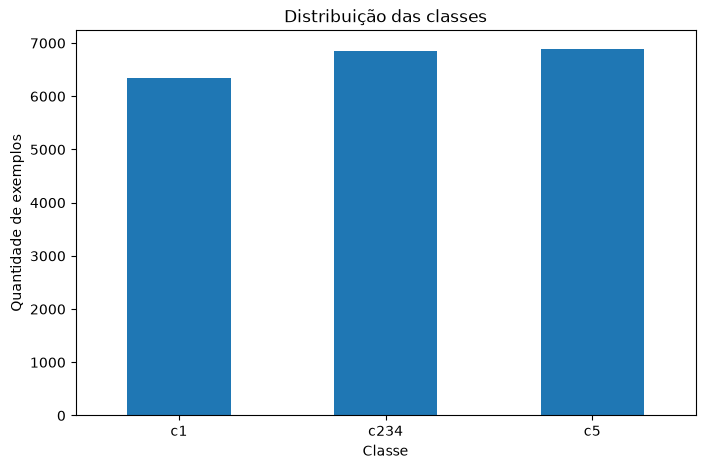

In [9]:
# Alteração: visualizamos graficamente a distribuição das classes para facilitar a identificação de desbalanceamento.

ax = y.value_counts().reindex(CLASSES).plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Distribuição das classes")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade de exemplos")

plt.xticks(rotation=0)
plt.show()

In [10]:
# Alteração: verificamos a existência de valores ausentes nas entradas textuais e nos rótulos.

print("Valores ausentes em X:", X.isna().sum())
print("Valores ausentes em y:", y.isna().sum())

Valores ausentes em X: 0
Valores ausentes em y: 0


In [11]:
# Alteração: verificamos a existência de textos vazios ou compostos apenas por espaços.

textos_vazios = X.astype(str).str.strip().eq("").sum()

print("Textos vazios:", textos_vazios)

Textos vazios: 0


In [12]:
# Alteração: adicionamos estatísticas básicas sobre o tamanho dos documentos para caracterizar o corpus.

tamanho_textos = X.astype(str).str.len()

print("Comprimento dos textos:")
print(tamanho_textos.describe())

Comprimento dos textos:
count    20092.000000
mean      1000.381644
std       1014.001503
min          7.000000
25%        338.000000
50%        709.000000
75%       1311.000000
max      12125.000000
Name: resp_text, dtype: float64


In [13]:
# Alteração: adicionamos uma análise complementar do número aproximado de palavras por documento.

quantidade_palavras = X.astype(str).str.split().str.len()

print("Quantidade de palavras por documento:")
print(quantidade_palavras.describe())

Quantidade de palavras por documento:
count    20092.000000
mean       144.274288
std        149.866288
min          1.000000
25%         47.000000
50%        101.000000
75%        188.000000
max       1821.000000
Name: resp_text, dtype: float64


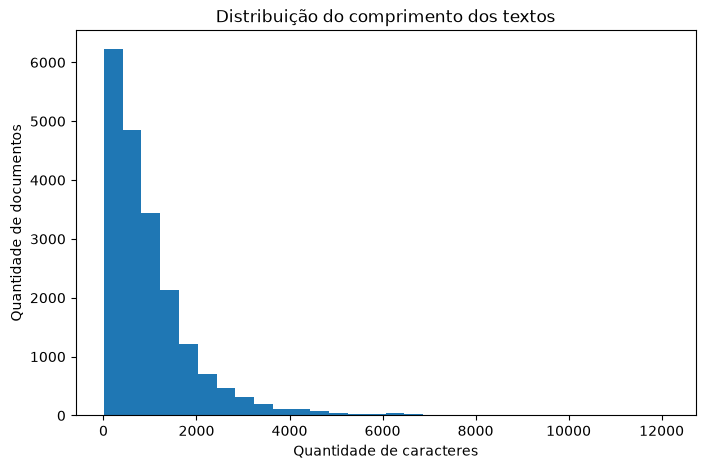

In [14]:
# Alteração: visualizamos a distribuição do comprimento dos textos para identificar documentos muito curtos ou longos.

plt.figure(figsize=(8, 5))

plt.hist(tamanho_textos, bins=30)

plt.title("Distribuição do comprimento dos textos")
plt.xlabel("Quantidade de caracteres")
plt.ylabel("Quantidade de documentos")

plt.show()

In [15]:
# Alteração: calculamos estatísticas do comprimento textual separadamente por classe para investigar diferenças no corpus.

analise_por_classe = pd.DataFrame({
    "classe": y.values,
    "tamanho_texto": tamanho_textos.values,
    "quantidade_palavras": quantidade_palavras.values
})

analise_por_classe.groupby("classe").agg({
    "tamanho_texto": ["mean", "median", "min", "max"],
    "quantidade_palavras": ["mean", "median", "min", "max"]
}).reindex(CLASSES)

tamanho_texto                   quantidade_palavras                 
                mean median min    max                mean median min   max
classe                                                                     
c1       1055.373090  782.0   7   9482          152.424610  111.0   1  1481
c234     1089.539180  794.0  11  12125          157.059974  112.0   1  1821
c5        861.085752  606.5   8  11822          124.055136   87.0   1  1763

## Conclusões da exploração

A exploração inicial permite caracterizar o conjunto de dados antes da aplicação dos modelos.

Nesta etapa devem ser registrados principalmente:

- quantidade total de exemplos;
- quantidade de classes;
- distribuição das classes;
- existência ou ausência de valores ausentes;
- presença de textos vazios;
- características gerais do tamanho dos documentos;
- possíveis sinais de desbalanceamento.

Essas informações serão consideradas na definição dos baselines e das métricas de avaliação.